# Comparación: CNN Funcional vs CNN Profunda y Red Siamés (MNIST)

**Objetivo:**  
1. Comparar dos arquitecturas CNN (modelo funcional base y una versión profunda con 4 convolucionales) entrenadas con MNIST bajo las mismas condiciones.  
2. Entrenar una red siamés con *contrastive loss* usando pares positivos/negativos generados a partir de MNIST.  
3. Realizar una comparación avanzada que relacione las predicciones de las CNN con las distancias aprendidas por la red siamés.

**Instrucciones de uso:**  
- Este notebook está listo para subir a Google Colab.  
- Ejecuta todas las celdas en orden.  
- Ajusta `epochs` y `batch_size` según tus recursos en Colab (GPU recomendado).  


In [124]:
# =========================
# 0) IMPORTS Y CONFIGURACIÓN
# =========================
# Importamos librerías básicas y Keras/TensorFlow
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import layers

# Configuración estética para gráficas
sns.set(font_scale=1.2)
plt.style.use('seaborn-v0_8-darkgrid')

# Fijamos una semilla para reproducibilidad (opcional)
np.random.seed(42)
tf.random.set_seed(42)

print('Librerías cargadas correctamente. TensorFlow version:', tf.__version__)


Librerías cargadas correctamente. TensorFlow version: 2.19.0


In [125]:
# ============================================
# 1) CARGA Y PREPROCESAMIENTO DEL DATASET MNIST
# ============================================
# Cargamos MNIST (imágenes 28x28 de dígitos 0-9)
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Normalizamos los pixeles a rango [0,1] y convertimos a float32
X_train = X_train.astype('float32') / 255.0
X_test  = X_test.astype('float32')  / 255.0

# Añadimos el canal de profundidad (1) → shape (N,28,28,1)
X_train = np.expand_dims(X_train, -1)
X_test  = np.expand_dims(X_test, -1)

# Convertimos etiquetas a one-hot para clasificación con las CNNs
y_train_cat = to_categorical(y_train, 10)
y_test_cat  = to_categorical(y_test, 10)

print('Shapes:')
print('  X_train:', X_train.shape)
print('  X_test :', X_test.shape)
print('  y_train (categorical):', y_train_cat.shape)
print('  y_test (categorical):', y_test_cat.shape)


Shapes:
  X_train: (60000, 28, 28, 1)
  X_test : (10000, 28, 28, 1)
  y_train (categorical): (60000, 10)
  y_test (categorical): (10000, 10)


In [126]:
# ============================================
# 2) DEFINICIÓN DE MODELOS CNN (FUNCIONAL Y PROFUNDO)
# ============================================
# MODELO A: CNN Funcional (base)
inputs1 = Input(shape=(28,28,1), name='input_funcional')
# Primera convolución + pooling
x1 = Conv2D(64, (3,3), activation='relu', name='conv1')(inputs1)  # 64 filtros 3x3
x1 = MaxPooling2D((2,2), name='pool1')(x1)                         # reduce espacialmente
# Segunda convolución + pooling
x1 = Conv2D(128, (3,3), activation='relu', name='conv2')(x1)      # 128 filtros 3x3
x1 = MaxPooling2D((2,2), name='pool2')(x1)
# Capa final densa
x1 = Flatten(name='flatten')(x1)
x1 = Dense(128, activation='relu', name='dense_128')(x1)
outputs1 = Dense(10, activation='softmax', name='output')(x1)

cnn_funcional = Model(inputs1, outputs1, name='CNN_Funcional')
cnn_funcional.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

# MODELO B: CNN Profunda (2 conv + pool, luego otras 2 conv + pool)
inputs2 = Input(shape=(28,28,1), name='input_profundo')
# Bloque 1: 2 convoluciones seguidas y pooling
x2 = Conv2D(32, (3,3), activation='relu', padding='same', name='conv2d_1')(inputs2)
x2 = Conv2D(64, (3,3), activation='relu', padding='same', name='conv2d_2')(x2)
x2 = MaxPooling2D((2,2), name='maxpool_1')(x2)
# Bloque 2: otras 2 convoluciones y pooling
x2 = Conv2D(128, (3,3), activation='relu', padding='same', name='conv2d_3')(x2)
x2 = Conv2D(256, (3,3), activation='relu', padding='same', name='conv2d_4')(x2)
x2 = MaxPooling2D((2,2), name='maxpool_2')(x2)
# Final
x2 = Flatten(name='flatten')(x2)
x2 = Dense(256, activation='relu', name='dense_256')(x2)
outputs2 = Dense(10, activation='softmax', name='output')(x2)

cnn_profundo = Model(inputs2, outputs2, name='CNN_Profundo')
cnn_profundo.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

print('\nModelos creados: CNN Funcional y CNN Profundo')



Modelos creados: CNN Funcional y CNN Profundo


In [127]:
# Mostrar resúmenes (arquitectura y parámetros)
print('\n--- Resumen: CNN Funcional ---')
cnn_funcional.summary()
print('\n--- Resumen: CNN Profundo ---')
cnn_profundo.summary()



--- Resumen: CNN Funcional ---


Model: "CNN_Funcional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_funcional (InputLayer)    │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 26, 26, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 13, 13, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 11, 11, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 5, 5, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_128 (Dense)               │ (None, 128)            │       409,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 485,514 (1.85 MB)

 Trainable params: 485,514 (1.85 MB)

...

Model: "CNN_Profundo"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_profundo (InputLayer)     │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool_1 (MaxPooling2D)        │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 14, 14, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool_2 (MaxPooling2D)        │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_256 (Dense)               │ (None, 256)            │     3,211,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,601,930 (13.74 MB)

 Trainable params: 3,601,930 (13.74 MB)

 Non-trainable params: 0 (0.00 B)

In [128]:
# ============================================
# 3) ENTRENAMIENTO: ambos modelos con mismas condiciones
# ============================================
epochs = 50        # Ajusta según recurso (Colab GPU: sube si quieres)
batch_size = 128

# Entrenamos primero la CNN funcional
history_funcional = cnn_funcional.fit(
    X_train, y_train_cat,
    validation_split=0.1,
    epochs=epochs,
    batch_size=batch_size,
    verbose=1
)

# Entrenamos la CNN profunda (mismas condiciones)
history_profundo = cnn_profundo.fit(
    X_train, y_train_cat,
    validation_split=0.1,
    epochs=epochs,
    batch_size=batch_size,
    verbose=1
)


Epoch 1/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.8765 - loss: 0.4146 - val_accuracy: 0.9842 - val_loss: 0.0543
Epoch 2/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9841 - loss: 0.0523 - val_accuracy: 0.9870 - val_loss: 0.0443
Epoch 3/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9893 - loss: 0.0340 - val_accuracy: 0.9885 - val_loss: 0.0386
Epoch 4/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9930 - loss: 0.0249 - val_accuracy: 0.9883 - val_loss: 0.0383
Epoch 5/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9942 - loss: 0.0194 - val_accuracy: 0.9882 - val_loss: 0.0409
Epoch 6/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9959 - loss: 0.0140 - val_accuracy: 0.9898 - val_loss: 0.0377
Epoch 7/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9967 - loss: 0.0104 - val_accuracy: 0.9892 - val_loss: 0.0439
Epoch 8/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9968 - loss: 0.0095 - val_accuracy: 0

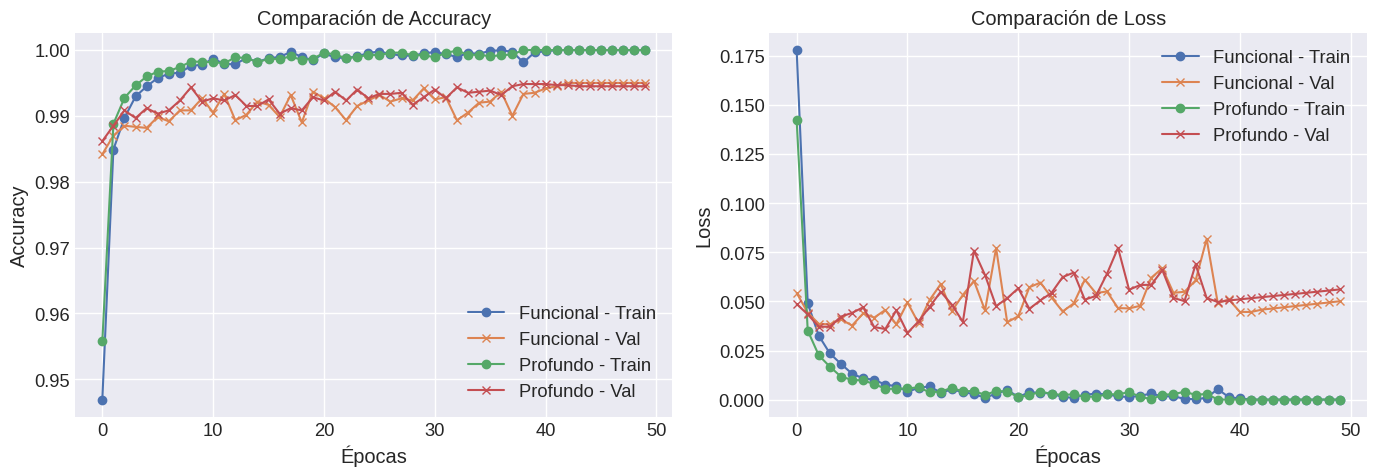

In [129]:
# ============================================
# 4) COMPARACIÓN VISUAL: Accuracy y Loss
# ============================================
plt.figure(figsize=(14,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history_funcional.history['accuracy'], marker='o', label='Funcional - Train')
plt.plot(history_funcional.history['val_accuracy'], marker='x', label='Funcional - Val')
plt.plot(history_profundo.history['accuracy'], marker='o', label='Profundo - Train')
plt.plot(history_profundo.history['val_accuracy'], marker='x', label='Profundo - Val')
plt.title('Comparación de Accuracy')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history_funcional.history['loss'], marker='o', label='Funcional - Train')
plt.plot(history_funcional.history['val_loss'], marker='x', label='Funcional - Val')
plt.plot(history_profundo.history['loss'], marker='o', label='Profundo - Train')
plt.plot(history_profundo.history['val_loss'], marker='x', label='Profundo - Val')
plt.title('Comparación de Loss')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


In [130]:
# ============================================
# 5) EVALUACIÓN FINAL: métricas en test set
# ============================================
loss_f, acc_f = cnn_funcional.evaluate(X_test, y_test_cat, verbose=0)
loss_p, acc_p = cnn_profundo.evaluate(X_test, y_test_cat, verbose=0)

print('\nRESULTADOS EN TEST:')
print(f'CNN Funcional -> Loss: {loss_f:.4f}, Accuracy: {acc_f:.4f}')
print(f'CNN Profundo  -> Loss: {loss_p:.4f}, Accuracy: {acc_p:.4f}')

if acc_p > acc_f:
    print('\n✅ La CNN profunda tiene mejor rendimiento general.')
else:
    print('\n📉 La CNN funcional conserva mejor precisión o estabilidad.')



RESULTADOS EN TEST:
CNN Funcional -> Loss: 0.0400, Accuracy: 0.9941
CNN Profundo  -> Loss: 0.0352, Accuracy: 0.9953

✅ La CNN profunda tiene mejor rendimiento general.


In [131]:
# ============================================
# 6) MODELO SIAMÉS - PREPARACIÓN DE PARES
# ============================================
# Aquí generamos pares positivos (mismo dígito) y negativos (dígitos distintos)
def make_pairs(images, labels):
    num_classes = 10
    digit_indices = [np.where(labels == i)[0] for i in range(num_classes)]
    pairs = []
    pair_labels = []
    # Recorremos cada imagen y construimos un par positivo y uno negativo
    for idx, img in enumerate(images):
        label = labels[idx]
        # positivo: otra imagen con la misma etiqueta
        pos_idx = np.random.choice(digit_indices[label])
        pos_img = images[pos_idx]
        # negativo: imagen con etiqueta distinta
        neg_label = (label + np.random.randint(1, num_classes)) % num_classes
        neg_idx = np.random.choice(digit_indices[neg_label])
        neg_img = images[neg_idx]
        pairs.append([img, pos_img])
        pair_labels.append(1.0)  # 1 → similar
        pairs.append([img, neg_img])
        pair_labels.append(0.0)  # 0 → distinto
    return np.array(pairs), np.array(pair_labels).astype('float32')

# Cargamos MNIST crudo (no one-hot) para pares
(x_train_pairs, y_train_pairs), (x_test_pairs, y_test_pairs) = mnist.load_data()
x_train_pairs = x_train_pairs.astype('float32') / 255.0
x_test_pairs  = x_test_pairs.astype('float32')  / 255.0
x_train_pairs = np.expand_dims(x_train_pairs, -1)
x_test_pairs  = np.expand_dims(x_test_pairs, -1)

# Generamos pares (esto duplica las muestras: 2 pares por imagen)
train_pairs, train_pair_labels = make_pairs(x_train_pairs, y_train_pairs)
test_pairs, test_pair_labels   = make_pairs(x_test_pairs, y_test_pairs)

print('Pares generados:')
print('  train_pairs shape:', train_pairs.shape)
print('  test_pairs  shape:', test_pairs.shape)


Pares generados:
  train_pairs shape: (120000, 2, 28, 28, 1)
  test_pairs  shape: (20000, 2, 28, 28, 1)


In [132]:
# ============================================
# 7) ENCODER (SUBRED) Y MODELO SIAMÉS
# ============================================
def build_encoder():
    inputs = tf.keras.Input((28,28,1))
    x = layers.Conv2D(64, (3,3), activation='relu')(inputs)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(128, (3,3), activation='relu')(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Flatten()(x)
    x = layers.Dense(128, activation='relu')(x)
    outputs = layers.Dense(64)(x)  # embedding vector (64 dims)
    return Model(inputs, outputs, name='Encoder')

encoder = build_encoder()
encoder.summary()

# Entradas del siamés: dos imágenes
input_A = layers.Input((28,28,1))
input_B = layers.Input((28,28,1))

# Pasamos ambas por el encoder compartido
emb_A = encoder(input_A)
emb_B = encoder(input_B)

# Distancia euclidiana entre embeddings
distance = layers.Lambda(
    lambda tensors: tf.sqrt(
        tf.reduce_sum(tf.square(tensors[0] - tensors[1]), axis=1, keepdims=True) + 1e-9
    )
)([emb_A, emb_B])


siamese_network = Model([input_A, input_B], distance, name='SiameseNet')
siamese_network.summary()


Model: "Encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_9 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 26, 26, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 13, 13, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 11, 11, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 5, 5, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 3200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       409,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 492,480 (1.88 MB)

 Trainable params: 492,480 (1.88 MB)

 Non-trainable params: 0 (0.00 B)

Model: "SiameseNet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_10      │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_11      │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Encoder             │ (None, 64)        │    492,480 │ input_layer_10[0… │
│ (Functional)        │                   │            │ input_layer_11[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_3 (Lambda)   │ (None, 1)         │          0 │ Encoder[0][0],    │
│                     │                   │            │ Encoder[1][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 492,480 (1.88 MB)

 Trainable params: 492,480 (1.88 MB)

 Non-trainable params: 0 (0.00 B)

In [133]:
# ============================================
# 8) PÉRDIDA CONTRASTIVA Y COMPILACIÓN
# ============================================
def contrastive_loss(y_true, y_pred, margin=1.0):
    # y_true: 1.0 si similar, 0.0 si distinto
    square_pred = tf.square(y_pred)
    margin_square = tf.square(tf.maximum(margin - y_pred, 0.0))
    return tf.reduce_mean(y_true * square_pred + (1.0 - y_true) * margin_square)

siamese_network.compile(optimizer=tf.keras.optimizers.Adam(0.001), loss=contrastive_loss)
print('Siamese compilado con contrastive_loss.')


Siamese compilado con contrastive_loss.


In [134]:
# ============================================
# 9) ENTRENAMIENTO DEL MODELO SIAMÉS
# ============================================
# Nota: reduce epochs si estás en entorno con recursos limitados
epochs_siamese = 50
batch_size_siamese = 128

history_siamese = siamese_network.fit(
    [train_pairs[:,0], train_pairs[:,1]], train_pair_labels,
    validation_data=([test_pairs[:,0], test_pairs[:,1]], test_pair_labels),
    epochs=epochs_siamese,
    batch_size=batch_size_siamese,
    verbose=1
)


Epoch 1/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 15s 13ms/step - loss: 0.0643 - val_loss: 0.0208
Epoch 2/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - loss: 0.0182 - val_loss: 0.0163
Epoch 3/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - loss: 0.0121 - val_loss: 0.0143
Epoch 4/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - loss: 0.0088 - val_loss: 0.0134
Epoch 5/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - loss: 0.0067 - val_loss: 0.0129
Epoch 6/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - loss: 0.0055 - val_loss: 0.0127
Epoch 7/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - loss: 0.0045 - val_loss: 0.0128
Epoch 8/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - loss: 0.0039 - val_loss: 0.0128
Epoch 9/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - loss: 0.0035 - val_loss: 0.0126
Epoch 10/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - loss: 0.0031 - val_loss: 0.0123
Epoch 11/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - loss: 0.0028 - val_loss: 0.0121
Epoch 12/50
938/938 ━━━━━━━━━━

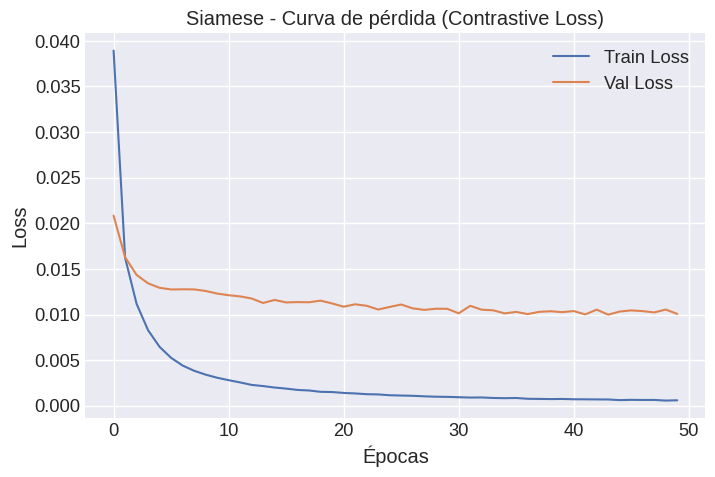

In [135]:
# ============================================
# 10) CURVA DE PÉRDIDA DEL SIAMÉS
# ============================================
plt.figure(figsize=(8,5))
plt.plot(history_siamese.history['loss'], label='Train Loss')
plt.plot(history_siamese.history['val_loss'], label='Val Loss')
plt.title('Siamese - Curva de pérdida (Contrastive Loss)')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()
plt.show()


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
Errores modelo Funcional: 59 / 10000
Errores modelo Profundo: 47 / 10000


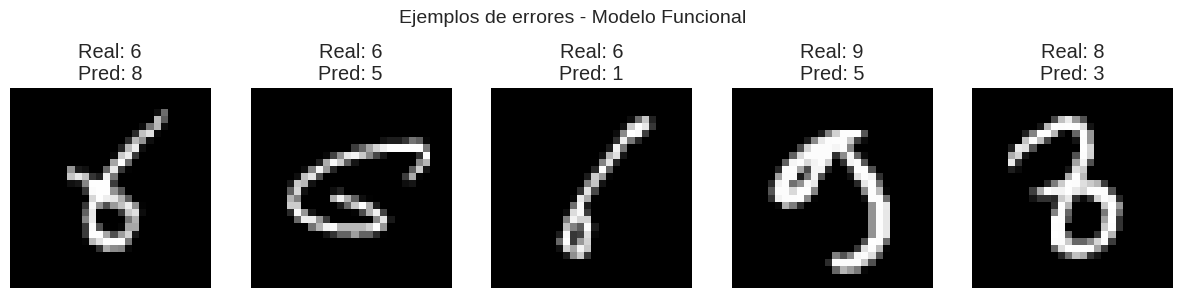

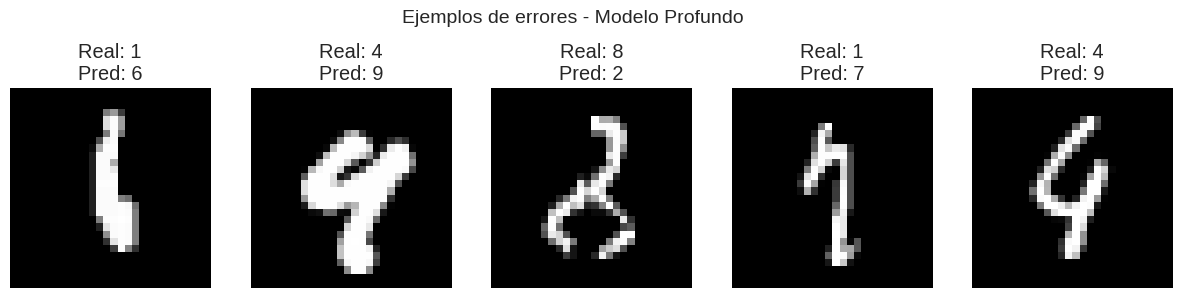

In [136]:
import numpy as np
import matplotlib.pyplot as plt
import random

# --- GENERAR PREDICCIONES ---
y_pred_func = cnn_funcional.predict(X_test)
y_pred_seq = cnn_profundo.predict(X_test)

# --- CONVERTIR A ETIQUETAS SI ES NECESARIO ---
y_true = np.argmax(y_test, axis=1) if y_test.ndim > 1 else y_test
y_pred_func = np.argmax(y_pred_func, axis=1) if y_pred_func.ndim > 1 else y_pred_func
y_pred_seq = np.argmax(y_pred_seq, axis=1) if y_pred_seq.ndim > 1 else y_pred_seq

# --- ENCONTRAR ERRORES ---
errores_func = np.where(y_pred_func != y_true)[0]
errores_seq = np.where(y_pred_seq != y_true)[0]

print(f"Errores modelo Funcional: {len(errores_func)} / {len(y_true)}")
print(f"Errores modelo Profundo: {len(errores_seq)} / {len(y_true)}")

# --- FUNCIÓN PARA MOSTRAR ERRORES ---
def mostrar_errores(indices_error, modelo_nombre, y_pred):
    if len(indices_error) == 0:
        print(f"✅ No hubo errores en el modelo {modelo_nombre}")
        return
    muestras = random.sample(list(indices_error), min(5, len(indices_error)))
    plt.figure(figsize=(15, 3))
    for i, idx in enumerate(muestras):
        plt.subplot(1, len(muestras), i + 1)
        plt.imshow(np.squeeze(X_test[idx]), cmap='gray')
        plt.title(f"Real: {y_true[idx]}\nPred: {y_pred[idx]}")
        plt.axis("off")

    # Ajustar suptitle y espaciado
    plt.suptitle(f"Ejemplos de errores - Modelo {modelo_nombre}", fontsize=14, y=1.05)
    plt.subplots_adjust(top=0.8)  # separa el suptitle de las imágenes
    plt.show()


# --- VISUALIZAR 5 ERRORES DE CADA UNO ---
mostrar_errores(errores_func, "Funcional", y_pred_func)
mostrar_errores(errores_seq, "Profundo", y_pred_seq)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 551ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


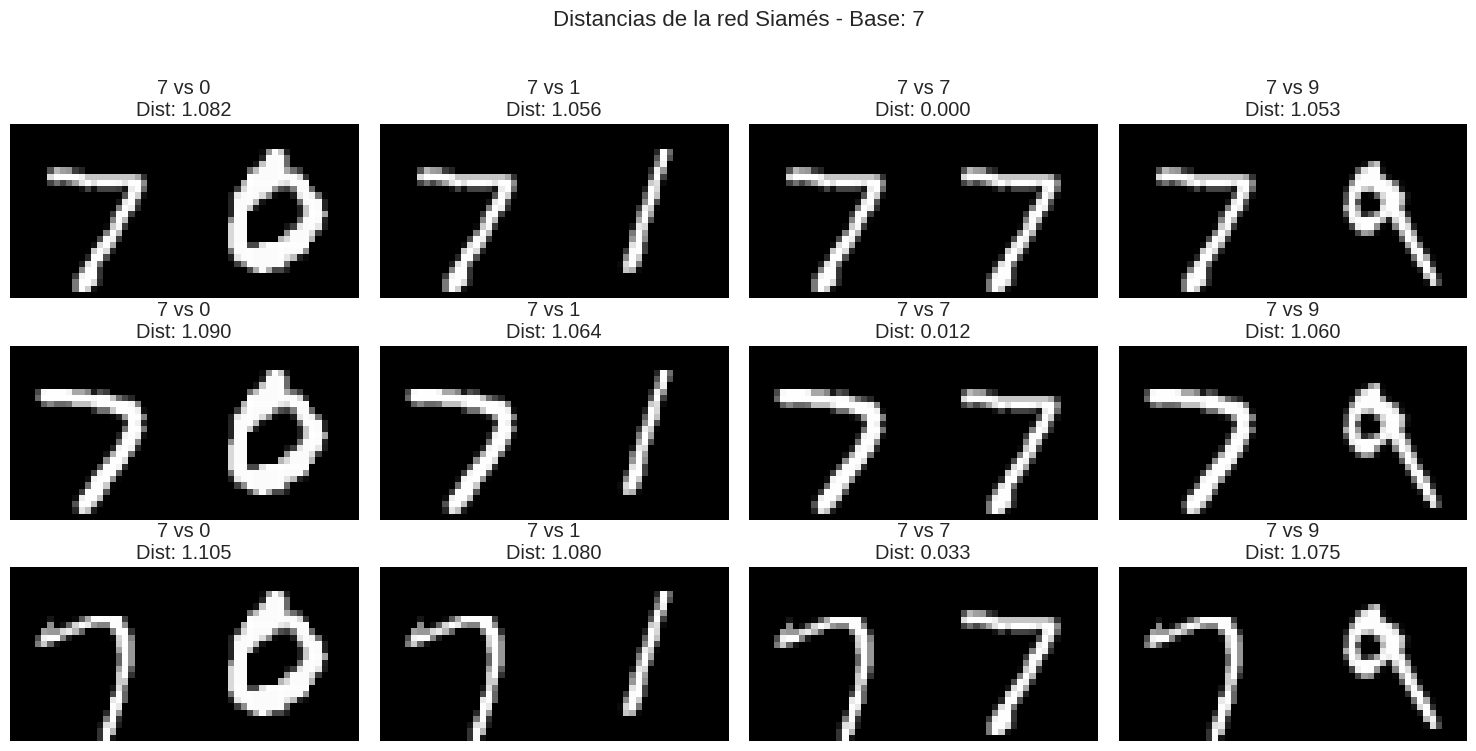

In [137]:
import random

def mostrar_errores_siamese(base_digit, digits_to_compare, samples, siamese_network, num_to_show=5):
    """
    Muestra errores o distancias significativas en la red siamés comparando una imagen base
    con otras imágenes de distintos dígitos.
    """

    base_samples = samples[base_digit]

    plt.figure(figsize=(15, num_to_show*2.5))

    for j in range(min(num_to_show, len(base_samples))):
        base_img = base_samples[j]

        # Comparamos con un ejemplo de cada dígito
        comparison_imgs = [samples[d][0] for d in digits_to_compare]

        distances = siamese_network.predict([
            np.repeat(base_img[np.newaxis,...], len(comparison_imgs), axis=0),
            np.array(comparison_imgs)
        ])

        for i, d in enumerate(digits_to_compare):
            plt.subplot(num_to_show, len(digits_to_compare), j*len(digits_to_compare) + i + 1)
            concat = np.concatenate([base_img.squeeze(), comparison_imgs[i].squeeze()], axis=1)
            plt.imshow(concat, cmap='gray')
            plt.title(f'{base_digit} vs {d}\nDist: {distances[i][0]:.3f}')
            plt.axis('off')

    plt.suptitle(f'Distancias de la red Siamés - Base: {base_digit}', fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

# Uso
mostrar_errores_siamese(base_digit=7, digits_to_compare=[0,1,7,9], samples=samples, siamese_network=siamese_network, num_to_show=3)


In [138]:
# Predicciones de CNN
y_pred_func = np.argmax(cnn_funcional.predict(X_test), axis=1)
y_pred_pro = np.argmax(cnn_profundo.predict(X_test), axis=1)
y_true      = np.argmax(y_test, axis=1) if y_test.ndim > 1 else y_test

# Errores en CNN
errores_func = np.where(y_pred_func != y_true)[0]
errores_seq  = np.where(y_pred_seq != y_true)[0]

print(f"Errores Funcional: {len(errores_func)}")
print(f"Errores Profundo : {len(errores_seq)}")


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Errores Funcional: 59
Errores Profundo : 47


In [139]:
# Solo revisamos las imágenes que fallaron en ambas CNN
errores_cnn = list(set(errores_func) & set(errores_seq))
print(f"Revisando solo {len(errores_cnn)} imágenes en el siamés...")

errores_siamese = []
umbral = 0.5  # ajusta según tu red

for idx in errores_cnn:
    digit = y_true[idx]

    # Tomamos solo una imagen de comparación aleatoria del mismo dígito
    same_digit_idxs = np.where(y_true == digit)[0]
    same_digit_idxs = same_digit_idxs[same_digit_idxs != idx]

    if len(same_digit_idxs) == 0:
        continue

    compare_idx = random.choice(same_digit_idxs)

    dist = siamese_network.predict([
        X_test[idx][np.newaxis,...],
        X_test[compare_idx][np.newaxis,...]
    ])[0][0]

    if dist > umbral:
        errores_siamese.append(idx)

# Intersección final: triple error
triple_error_idx = errores_siamese
print(f"Número de imágenes con error en las 3 redes: {len(triple_error_idx)}")


Revisando solo 27 imágenes en el siamés...
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 502ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━

In [140]:
triple_error_idx = list(set(errores_func) & set(errores_seq) & set(errores_siamese))
print(f"Número de imágenes con error en las 3 redes: {len(triple_error_idx)}")


Número de imágenes con error en las 3 redes: 21


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


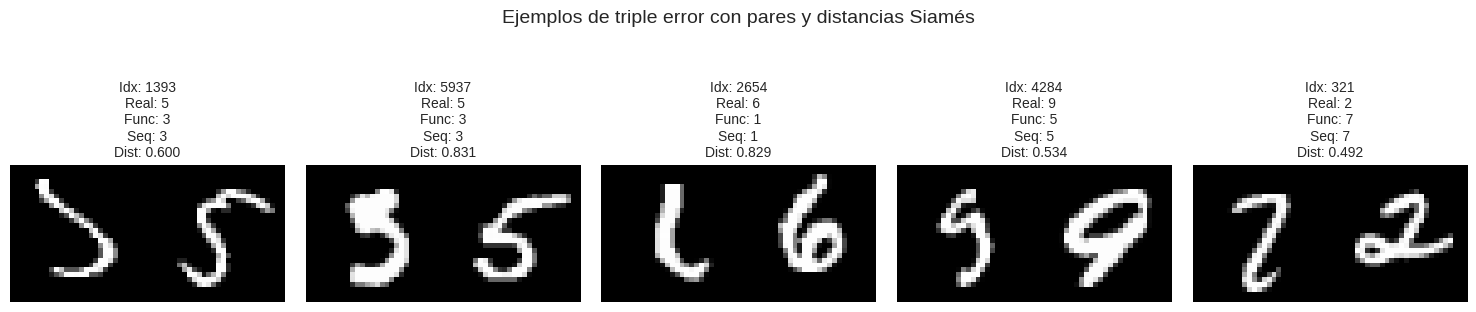

In [141]:
import random
num_show = min(5, len(triple_error_idx))
plt.figure(figsize=(15,3))

for i, idx in enumerate(random.sample(triple_error_idx, num_show)):
    plt.subplot(1, num_show, i+1)

    # Imagen base
    base_img = X_test[idx]
    digit = y_true[idx]

    # Elegimos otra imagen del mismo dígito para comparar
    same_digit_idxs = np.where(y_true == digit)[0]
    same_digit_idxs = same_digit_idxs != idx
    compare_idx = random.choice(np.where(y_true == digit)[0])

    compare_img = X_test[compare_idx]

    # Calculamos distancia del siamés
    dist = siamese_network.predict([
        base_img[np.newaxis,...],
        compare_img[np.newaxis,...]
    ])[0][0]

    # Concatenamos horizontalmente la base y la comparación
    pair_img = np.concatenate([base_img.squeeze(), compare_img.squeeze()], axis=1)

    # Título mejorado
    plt.imshow(pair_img, cmap='gray')
    plt.title(f"Idx: {idx}\nReal: {digit}\nFunc: {y_pred_func[idx]}\nSeq: {y_pred_pro[idx]}\nDist: {dist:.3f}", fontsize=10)
    plt.axis("off")

plt.suptitle("Ejemplos de triple error con pares y distancias Siamés", fontsize=14, y=1.15)
plt.tight_layout()
plt.show()



In [142]:
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.models import Model

def plot_conv_filters(model, img, layer_name, model_name="CNN"):
    """
    Grafica los mapas de activación de una capa convolucional para una imagen de entrada.
    """
    # Aseguramos batch dimension
    if img.ndim == 3:
        img = img[np.newaxis, ...]

    # Creamos submodelo para extraer activaciones
    act_model = Model(inputs=model.input, outputs=model.get_layer(layer_name).output)
    activations = act_model.predict(img)  # shape: (1,H,W,C)

    # Eliminamos batch
    activations = activations[0]

    n_filters = activations.shape[-1]
    n_cols = 8
    n_rows = int(np.ceil(n_filters / n_cols))

    plt.figure(figsize=(n_cols*2, n_rows*2))

    for i in range(n_filters):
        plt.subplot(n_rows, n_cols, i+1)
        plt.imshow(activations[:, :, i], cmap='viridis')
        plt.axis('off')
        plt.title(f"F{i+1}", fontsize=8)

    plt.suptitle(f"Activaciones de {layer_name} - {model_name}", fontsize=14)
    plt.tight_layout()
    plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


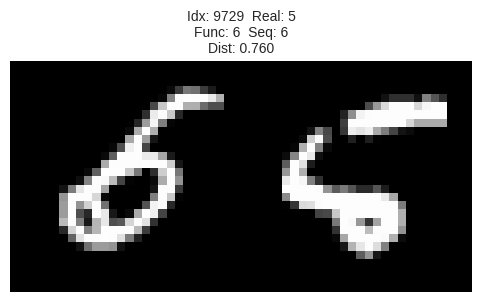

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step


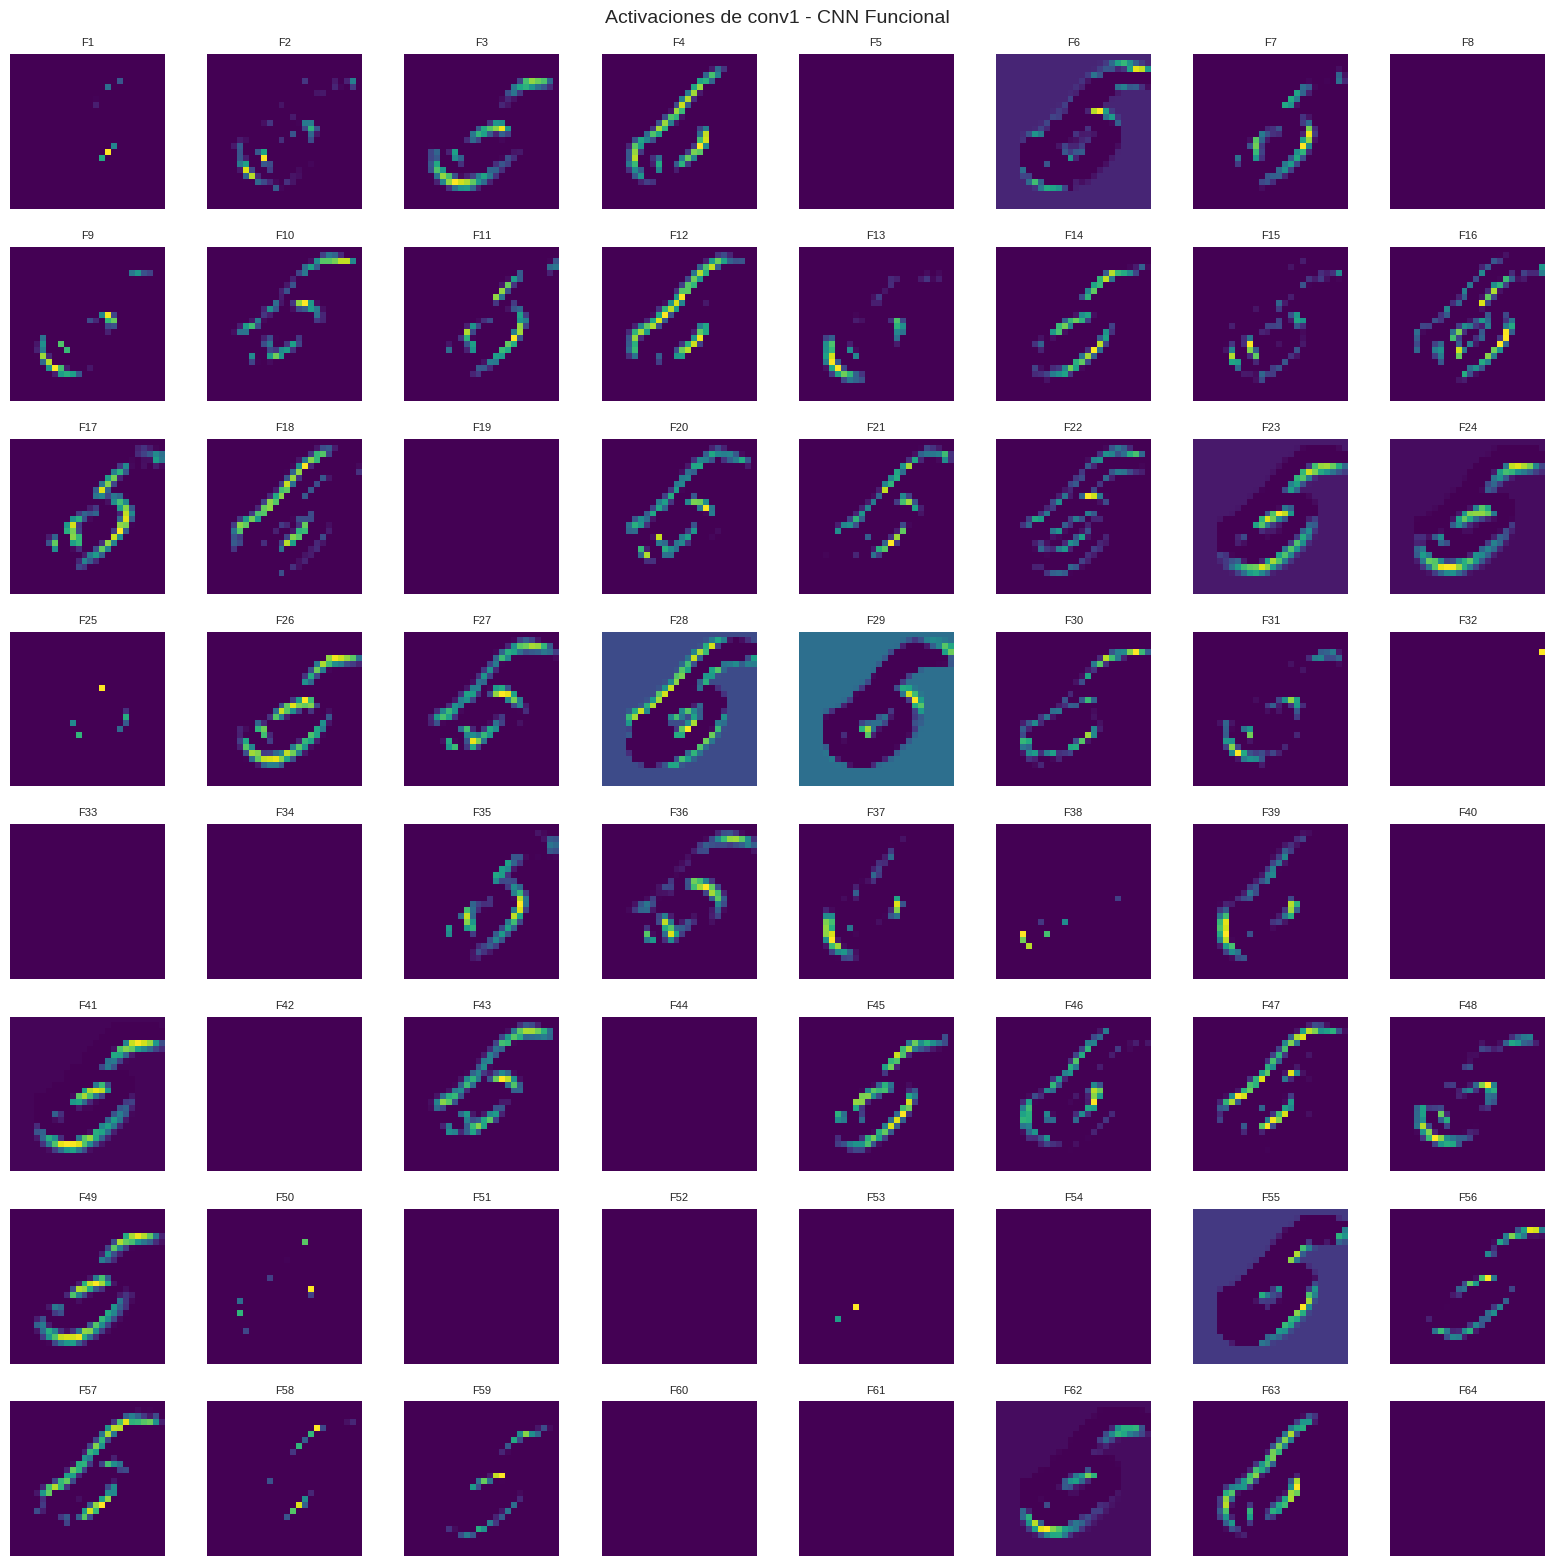

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step


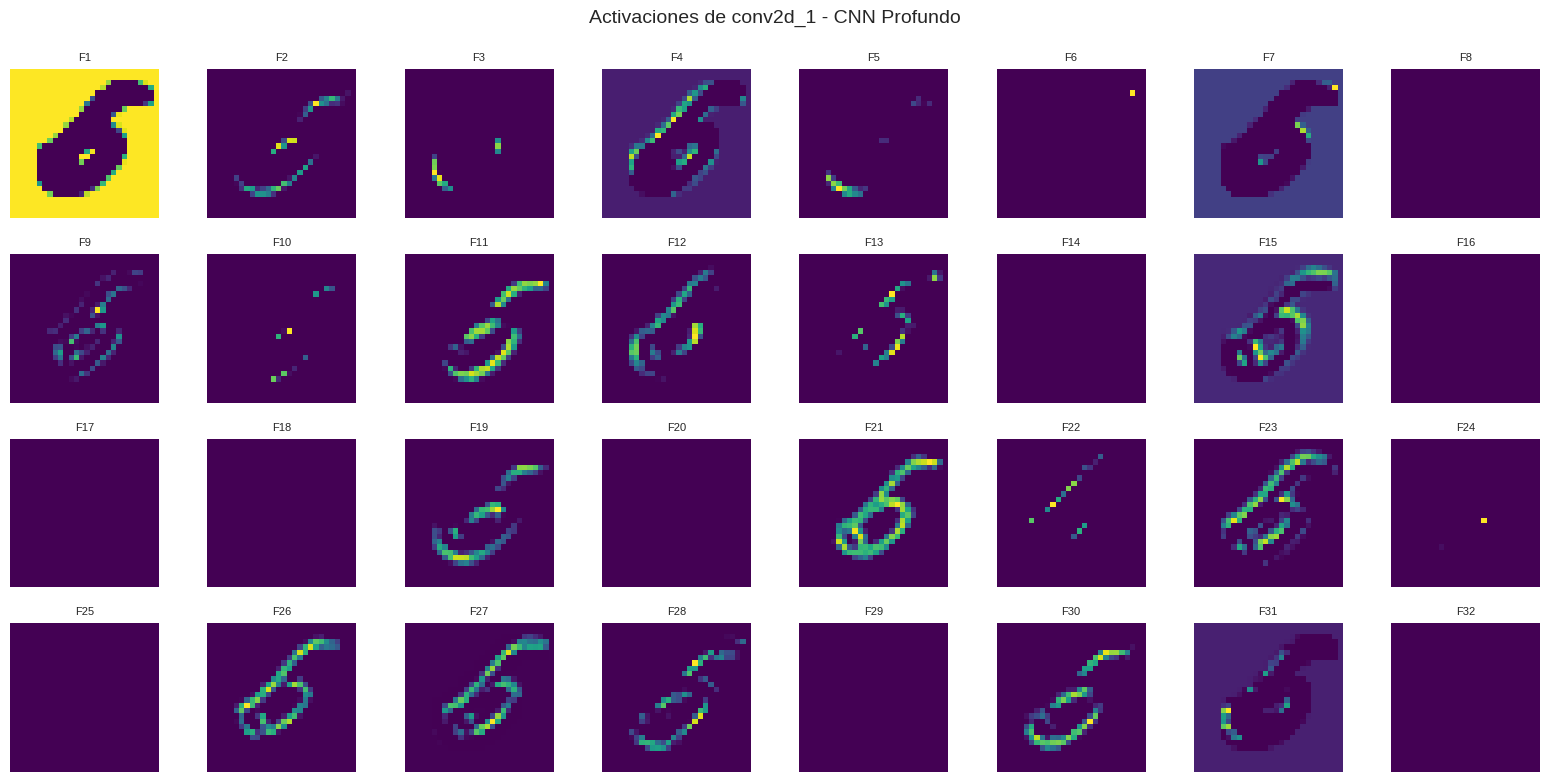

In [143]:
# Tomamos el primer índice de triple_error_idx
idx = triple_error_idx[0]
base_img = X_test[idx]
digit = y_true[idx]

# Mostramos el par Siamese
same_digit_idxs = np.where(y_true == digit)[0]
same_digit_idxs = same_digit_idxs[same_digit_idxs != idx]
compare_idx = same_digit_idxs[0]  # el primer otro ejemplo del mismo dígito
compare_img = X_test[compare_idx]

# Calculamos la distancia Siamese
dist = siamese_network.predict([
    base_img[np.newaxis,...],
    compare_img[np.newaxis,...]
])[0][0]

# Concatenamos para visualizar el par
pair_img = np.concatenate([base_img.squeeze(), compare_img.squeeze()], axis=1)

plt.figure(figsize=(6,3))
plt.imshow(pair_img, cmap='gray')
plt.title(f"Idx: {idx}  Real: {digit}\nFunc: {y_pred_func[idx]}  Seq: {y_pred_seq[idx]}\nDist: {dist:.3f}", fontsize=10)
plt.axis("off")
plt.show()

# --- Ahora mostramos los filtros de esa misma imagen ---
# Funcional
plot_conv_filters(cnn_funcional, base_img, layer_name="conv1", model_name="CNN Funcional")

# Profundo
plot_conv_filters(cnn_profundo, base_img, layer_name="conv2d_1", model_name="CNN Profundo")



In [144]:
import random
import numpy as np

# Selección de un ejemplo con error
num_show = min(5, len(triple_error_idx))
selected_idxs = random.sample(list(triple_error_idx), num_show)

idx = selected_idxs[0]
base_img = X_test[idx]
digit = y_true[idx]

# Seleccion de la imagen
idx = triple_error_idx[0]
base_img = X_test[idx]
digit = y_true[idx]

same_digit_idxs = np.where(y_true == digit)[0]
same_digit_idxs = same_digit_idxs[same_digit_idxs != idx]
compare_idx = same_digit_idxs[0]
compare_img = X_test[compare_idx]


# Predicción de distancia Siamese
dist = siamese_network.predict([
    base_img[np.newaxis,...],
    compare_img[np.newaxis,...]
])[0][0]

# Predicciones y softmax de las CNNs
probs_func = cnn_funcional.predict(base_img[np.newaxis,...])[0]
probs_seq  = cnn_profundo.predict(base_img[np.newaxis,...])[0]

pred_func = np.argmax(probs_func)
pred_seq  = np.argmax(probs_seq)

# Porcentajes de error / similitud
real_conf_func = probs_func[digit] * 100
real_conf_seq  = probs_seq[digit] * 100

cnn_func_error = 100 - probs_func[digit]*100  # cuánto se aleja de 100% la probabilidad real
cnn_seq_error  = 100 - probs_seq[digit]*100


siamese_error = dist * 100
siamese_similarity = (1 - dist) * 100

print(f"CNN Funcional -> Error de confianza: {cnn_func_error:.2f}%")
print(f"CNN Profunda  -> Error de confianza: {cnn_seq_error:.2f}%")
print(f"Siamésa       -> Distancia: {dist:.3f}  (Error {siamese_error:.1f}%, Similitud {siamese_similarity:.1f}%)")



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 307ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 336ms/step
CNN Funcional -> Error de confianza: 100.00%
CNN Profunda  -> Error de confianza: 99.75%
Siamésa       -> Distancia: 0.760  (Error 76.0%, Similitud 24.0%)


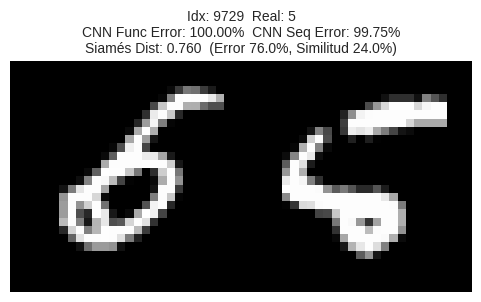

In [145]:
import matplotlib.pyplot as plt

pair_img = np.concatenate([base_img.squeeze(), compare_img.squeeze()], axis=1)

plt.figure(figsize=(6,3))
plt.imshow(pair_img, cmap='gray')
plt.title(f"Idx: {idx}  Real: {digit}\n"
          f"CNN Func Error: {cnn_func_error:.2f}%  CNN Seq Error: {cnn_seq_error:.2f}%\n"
          f"Siamés Dist: {dist:.3f}  (Error {siamese_error:.1f}%, Similitud {siamese_similarity:.1f}%)",
          fontsize=10)
plt.axis("off")
plt.show()



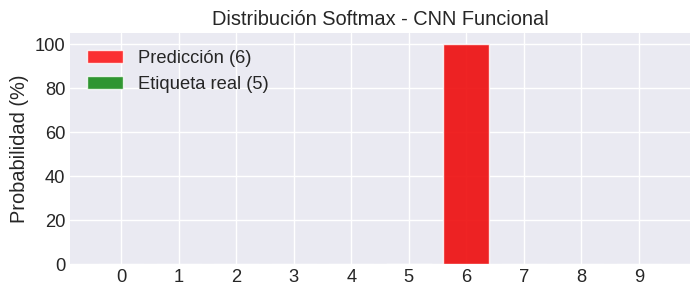

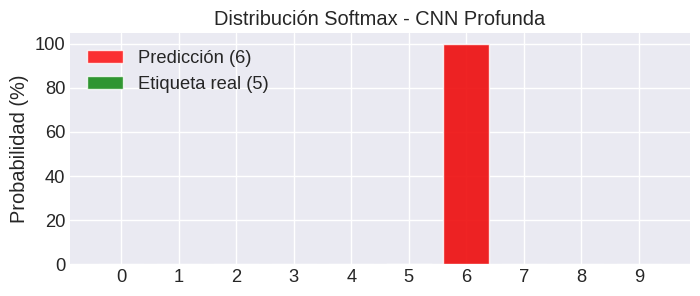

In [146]:
def plot_softmax(probs, true_label, pred_label, model_name):
    plt.figure(figsize=(8,3))
    plt.bar(range(len(probs)), probs*100, color='gray', alpha=0.6)
    plt.bar(pred_label, probs[pred_label]*100, color='red', alpha=0.8, label=f"Predicción ({pred_label})")
    plt.bar(true_label, probs[true_label]*100, color='green', alpha=0.8, label=f"Etiqueta real ({true_label})")
    plt.xticks(range(10))
    plt.ylabel("Probabilidad (%)")
    plt.title(f"Distribución Softmax - {model_name}")
    plt.legend()
    plt.show()

plot_softmax(probs_func, true_label=digit, pred_label=pred_func, model_name="CNN Funcional")
plot_softmax(probs_seq, true_label=digit, pred_label=pred_seq, model_name="CNN Profunda")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step


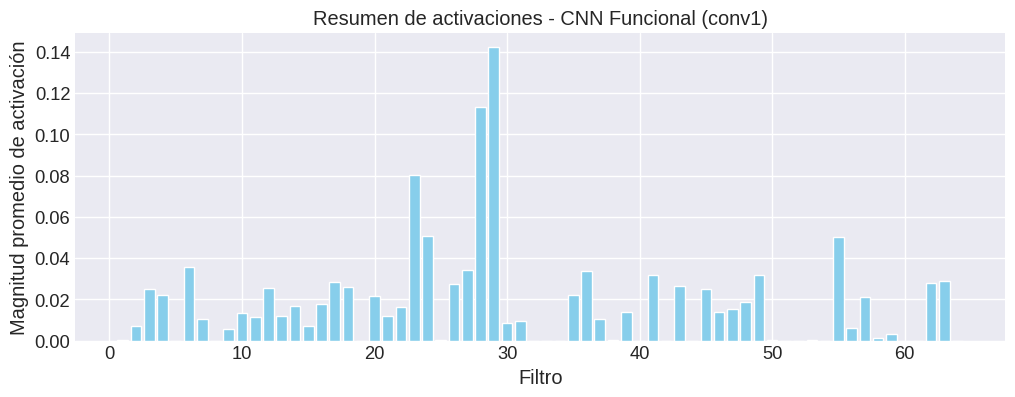

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 225ms/step


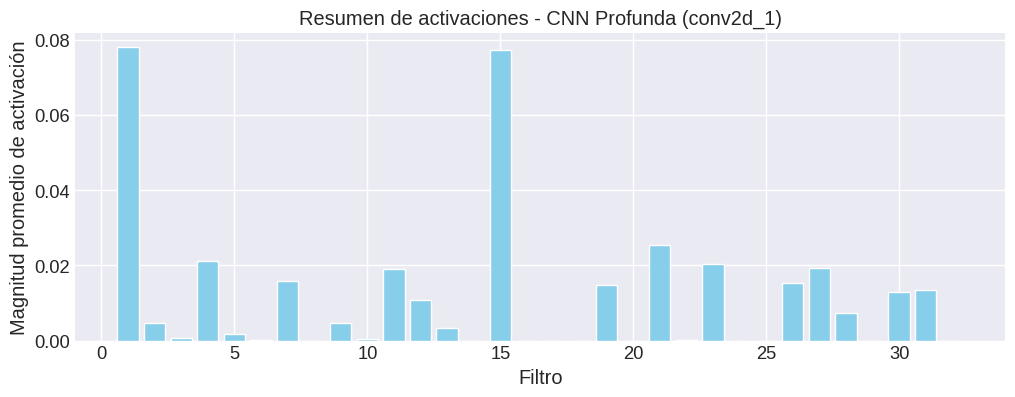

In [147]:
def plot_activation_summary(model, img, layer_name, model_name="CNN"):
    from tensorflow.keras.models import Model
    import matplotlib.pyplot as plt
    import numpy as np

    # Aseguramos batch
    if img.ndim == 3:
        img = img.reshape(1, *img.shape)

    # Modelo intermedio para activaciones
    conv_model = Model(inputs=model.input, outputs=model.get_layer(layer_name).output)
    activations = conv_model.predict(img)  # shape: (1,H,W,C)

    # Promedio absoluto de activaciones por filtro
    avg_activations = np.mean(np.abs(activations), axis=(1,2))  # shape: (1,C)
    avg_activations = avg_activations.flatten()

    # Gráfica
    plt.figure(figsize=(12,4))
    plt.bar(range(1, len(avg_activations)+1), avg_activations, color='skyblue')
    plt.xlabel("Filtro")
    plt.ylabel("Magnitud promedio de activación")
    plt.title(f"Resumen de activaciones - {model_name} ({layer_name})")
    plt.show()

# Funcional
plot_activation_summary(cnn_funcional, base_img, layer_name="conv1", model_name="CNN Funcional")

# Profundo
plot_activation_summary(cnn_profundo, base_img, layer_name="conv2d_1", model_name="CNN Profunda")



## Referencias
- Keras API Documentation: https://keras.io/api/  
- TensorFlow MNIST Dataset: https://www.tensorflow.org/datasets/catalog/mnist  
- Keras Example: Siamese Network with Contrastive Loss: https://keras.io/examples/vision/siamese_contrastive  
- Hadsell, R., Chopra, S., & LeCun, Y. (2006). *Dimensionality Reduction by Learning an Invariant Mapping.* CVPR 2006.  
- Chollet, F. (2017). *Deep Learning with Python.* Manning Publications.  
- Goodfellow, I., Bengio, Y., & Courville, A. (2016). *Deep Learning.* MIT Press.
